# COCOMO-81 Effort Prediction

Predict software development effort (person-months) from project size (KLOC) and 15 cost-driver multipliers.

Effort spans 3 orders of magnitude so all models are trained on **log(effort)** and predictions are exponentiated back.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib, warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [29]:
df = pd.read_csv("../dataset/COCOMO-81.csv")
print(f"Shape: {df.shape}")
print(f"Effort range: {df['actual'].min()} – {df['actual'].max()} person-months")
df.head()

Shape: (63, 19)
Effort range: 5.9 – 11400.0 person-months


,num,dev_mode,rely,data,cplx,time,stor,virt,turn,acap,aexp,pcap,vexp,lexp,modp,tool,sced,loc,actual
0,1,embedded,0.88,1.16,0.70,1.0,1.06,1.15,1.07,1.19,1.13,1.17,1.1,1.00,1.24,1.10,1.04,113.0,2040.0
1,2,embedded,0.88,1.16,0.85,1.0,1.06,1.00,1.07,1.00,0.91,1.00,0.9,0.95,1.10,1.00,1.00,293.0,1600.0
2,3,semidetached,1.00,1.16,0.85,1.0,1.00,0.87,0.94,0.86,0.82,0.86,0.9,0.95,0.91,0.91,1.00,132.0,243.0
3,4,organic,0.75,1.16,0.70,1.0,1.00,0.87,1.00,1.19,0.91,1.42,1.0,0.95,1.24,1.00,1.04,60.0,240.0
4,5,organic,0.88,0.94,1.00,1.0,1.00,0.87,1.00,1.00,1.00,0.86,0.9,0.95,1.24,1.00,1.00,16.0,33.0


## 2. Preprocess

One-hot encode `dev_mode` and take `log` of both size and effort — this linearises the COCOMO power-law relationship.

In [30]:
df_enc = pd.get_dummies(df, columns=['dev_mode'], drop_first=True)

COST_DRIVERS = ['rely','data','cplx','time','stor','virt','turn',
                'acap','aexp','pcap','vexp','lexp','modp','tool','sced']
DEV_MODE_COLS = [c for c in df_enc.columns if c.startswith('dev_mode_')]
FEATURES = ['log_loc'] + COST_DRIVERS + DEV_MODE_COLS

df_enc['log_loc']    = np.log(df_enc['loc'])
df_enc['log_effort'] = np.log(df_enc['actual'])

X = df_enc[FEATURES]
y = df_enc['log_effort']

print("Features:", FEATURES)

Features: ['log_loc', 'rely', 'data', 'cplx', 'time', 'stor', 'virt', 'turn', 'acap', 'aexp', 'pcap', 'vexp', 'lexp', 'modp', 'tool', 'sced', 'dev_mode_organic', 'dev_mode_semidetached']


## 3. Train / Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

Train: 50  Test: 13


## 4. Train & Evaluate Models

Metrics are computed in **original person-months** (predictions are exp-transformed back).

In [32]:
models = {
    "Linear Regression":  LinearRegression(),
    "Ridge Regression":   Ridge(alpha=1.0),
    "Random Forest":      RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting":  GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                     max_depth=3, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds_log = model.predict(X_test)
    preds     = np.exp(preds_log)
    actual    = np.exp(y_test)

    mae  = mean_absolute_error(actual, preds)
    rmse = np.sqrt(mean_squared_error(actual, preds))
    r2   = r2_score(actual, preds)
    # CV on log scale — lower is better
    cv_mae_log = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error').mean()

    results.append({"Model": name, "MAE (pm)": round(mae,1), "RMSE (pm)": round(rmse,1),
                    "R²": round(r2,3), "CV MAE log": round(cv_mae_log,3)})
    print(f"{name:22s}  MAE={mae:6.1f} pm  RMSE={rmse:7.1f} pm  R²={r2:.3f}  CV-log={cv_mae_log:.3f}")

results_df = pd.DataFrame(results).sort_values("CV MAE log")
results_df

Linear Regression       MAE= 103.4 pm  RMSE=  186.8 pm  R²=0.887  CV-log=0.483
Ridge Regression        MAE= 151.3 pm  RMSE=  296.5 pm  R²=0.716  CV-log=0.449
Random Forest           MAE= 231.0 pm  RMSE=  500.1 pm  R²=0.191  CV-log=0.741
Gradient Boosting       MAE= 239.0 pm  RMSE=  472.9 pm  R²=0.276  CV-log=0.702


,Model,MAE (pm),RMSE (pm),R²,CV MAE log
1,Ridge Regression,151.3,296.5,0.716,0.449
0,Linear Regression,103.4,186.8,0.887,0.483
3,Gradient Boosting,239.0,472.9,0.276,0.702
2,Random Forest,231.0,500.1,0.191,0.741


## 5. Feature Importance

Best model: Ridge Regression


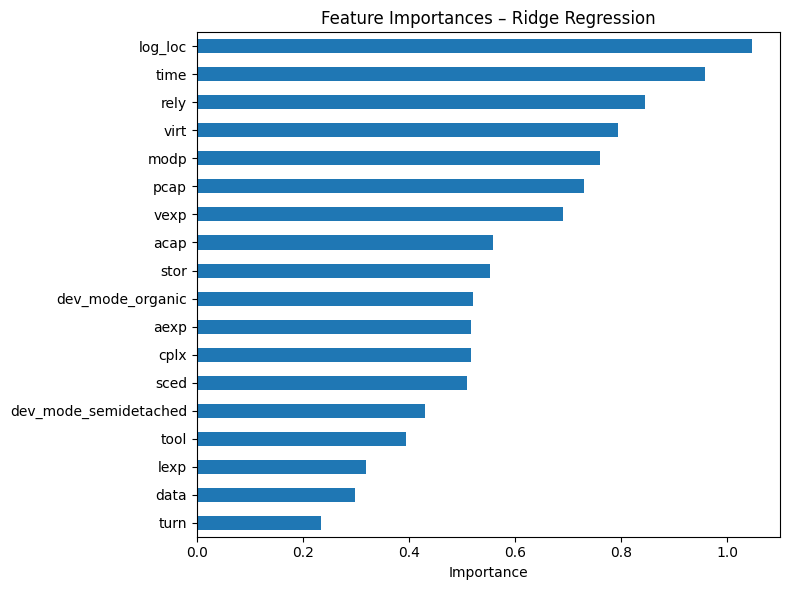

In [33]:
best_name  = results_df.iloc[0]['Model']
best_model = models[best_name]
print(f"Best model: {best_name}")

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
else:
    imp = pd.Series(np.abs(best_model.coef_), index=FEATURES).sort_values(ascending=True)

imp.plot(kind='barh', figsize=(8, 6), title=f'Feature Importances – {best_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 6. Actual vs Predicted

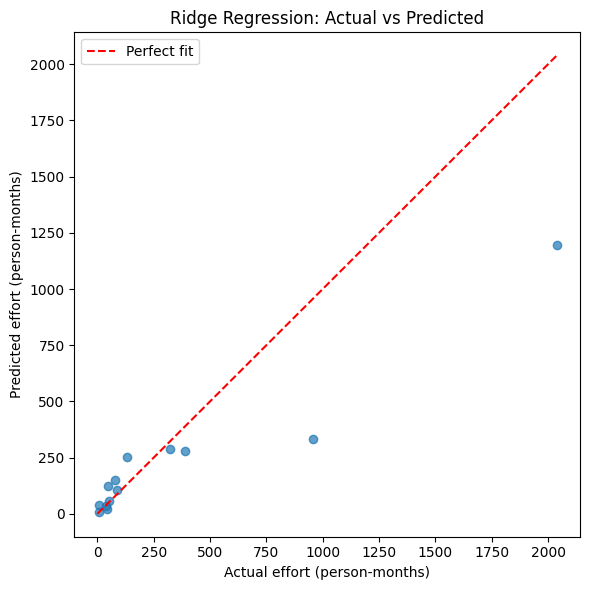

In [34]:
preds = np.exp(best_model.predict(X_test))
actual = np.exp(y_test)

plt.figure(figsize=(6, 6))
plt.scatter(actual, preds, alpha=0.7)
lim = max(actual.max(), preds.max())
plt.plot([0, lim], [0, lim], 'r--', label='Perfect fit')
plt.xlabel('Actual effort (person-months)')
plt.ylabel('Predicted effort (person-months)')
plt.title(f'{best_name}: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Save Model

In [35]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(best_model, "../models/effort_model.pkl")
joblib.dump(FEATURES,   "../models/features.pkl")
print(f"Saved: {best_name} → ../models/effort_model.pkl")

Saved: Ridge Regression → ../models/effort_model.pkl


## 8. Predict a New Project

Provide your project's size in KLOC and any cost driver multipliers that differ from nominal (1.0).

| Rating     | Multiplier range |
|------------|-----------------|
| Very Low   | 0.70 – 0.87     |
| Low        | 0.86 – 0.94     |
| Nominal    | 1.00            |
| High       | 1.06 – 1.15     |
| Very High  | 1.21 – 1.40     |
| Extra High | 1.56 – 1.66     |


In [36]:
def predict_effort(loc, dev_mode='organic', **cost_drivers):
    """
    Predict software development effort in person-months.

    Parameters
    ----------
    loc : float
        Project size in KLOC (thousands of lines of code).
    dev_mode : str
        'organic', 'semidetached', or 'embedded'.
    **cost_drivers : float
        Any COCOMO-81 cost driver at a non-nominal value.
        Unspecified drivers default to 1.0 (nominal).
        Options: rely, data, cplx, time, stor, virt, turn,
                 acap, aexp, pcap, vexp, lexp, modp, tool, sced
    """
    model    = joblib.load("../models/effort_model.pkl")
    feat_names = joblib.load("../models/features.pkl")

    cd_defaults = {cd: 1.0 for cd in ['rely','data','cplx','time','stor','virt',
                                        'turn','acap','aexp','pcap','vexp','lexp',
                                        'modp','tool','sced']}
    cd_defaults.update(cost_drivers)

    row = {'log_loc': np.log(loc)}
    row.update(cd_defaults)
    row['dev_mode_organic']      = 1 if dev_mode == 'organic'      else 0
    row['dev_mode_semidetached'] = 1 if dev_mode == 'semidetached' else 0

    effort = np.exp(model.predict(pd.DataFrame([row])[feat_names])[0])
    print(f"Estimated effort: {effort:.1f} person-months  (~{effort/12:.1f} person-years)")
    return effort


# --- Example: 50 KLOC organic project, experienced analysts (acap=0.71) ---
predict_effort(loc=50, dev_mode='organic', acap=0.71, aexp=1.13)

Estimated effort: 155.6 person-months  (~13.0 person-years)


np.float64(155.60464907439507)